In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

class FERDataset(Dataset):

    LABEL_MAP = {
        "neutral": 0, "angry": 1, "happy": 2,
        "disgust": 3, "sad": 4, "surprise": 5, "fear": 6,
    }

    def __init__(self, data_dir: str, is_train: bool = True):
        self.data_dir = data_dir
        self.is_train = is_train
        self.image_paths: list[str] = []
        self.labels: list[int] = []

        for emotion_folder in os.listdir(data_dir):
            key = emotion_folder.lower()
            if key in self.LABEL_MAP:
                folder_path = os.path.join(data_dir, emotion_folder)
                label_idx = self.LABEL_MAP[key]
                for img_name in os.listdir(folder_path):
                    self.image_paths.append(os.path.join(folder_path, img_name))
                    self.labels.append(label_idx)

        self.label_to_indices: dict[int, list[int]] = {}
        for idx, lbl in enumerate(self.labels):
            self.label_to_indices.setdefault(lbl, []).append(idx)

        base = [
            transforms.ToPILImage(),
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((112, 112)),
        ]
        augment = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ] if is_train else []

        self.transform = transforms.Compose(
            base + augment + [
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ]
        )

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        label_M = self.labels[idx]

        img_M = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)

        candidates = self.label_to_indices[label_M]
        idx_N = random.choice(candidates)
        img_N = cv2.cvtColor(cv2.imread(self.image_paths[idx_N]), cv2.COLOR_BGR2RGB)

        return self.transform(img_M), self.transform(img_N), label_M

In [ ]:

class ResNetEncoder(nn.Module):

    def __init__(self, feature_dim: int = 64):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.features = nn.Sequential(*list(resnet.children())[:-1])

        self.fc = nn.Linear(resnet.fc.in_features, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.bn(self.fc(x))

class Discriminator(nn.Module):

    def __init__(self, feature_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim * 2, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, expr: torch.Tensor, ident: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([expr, ident], dim=1))

class Classifier(nn.Module):

    def __init__(self, feature_dim: int = 64, num_classes: int = 7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [ ]:

def train_dice_fer(
    data_dir: str = "real_data/CK+48",
    epochs: int = 100,
    batch_size: int = 32,
    lr: float = 1e-4,
    feature_dim: int = 64,
    num_classes: int = 7,
    lambda_cls: float = 1.0,
    lambda_adv: float = 0.1,
    use_dummy: bool = False,
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    E_exp   = ResNetEncoder(feature_dim).to(device)
    E_id    = ResNetEncoder(feature_dim).to(device)
    D       = Discriminator(feature_dim).to(device)
    C       = Classifier(feature_dim, num_classes).to(device)

    opt_exp_cls = optim.Adam(
        list(E_exp.parameters()) + list(C.parameters()), lr=lr
    )
    opt_id      = optim.Adam(E_id.parameters(), lr=lr)
    opt_disc    = optim.Adam(D.parameters(), lr=lr * 2)

    sched_exp_cls = optim.lr_scheduler.CosineAnnealingLR(opt_exp_cls, T_max=epochs)
    sched_id      = optim.lr_scheduler.CosineAnnealingLR(opt_id, T_max=epochs)
    sched_disc    = optim.lr_scheduler.CosineAnnealingLR(opt_disc, T_max=epochs)

    crit_l1  = nn.L1Loss()
    crit_bce = nn.BCELoss()
    crit_ce  = nn.CrossEntropyLoss()

    ck_class_counts = torch.tensor([45, 135, 207, 177, 84, 249, 75], dtype=torch.float)
    class_weights   = (1.0 / ck_class_counts)
    class_weights   = (class_weights / class_weights.sum() * num_classes).to(device)
    crit_ce_weighted = nn.CrossEntropyLoss(weight=class_weights)

    if use_dummy:
        from torch.utils.data import TensorDataset
        dummy_M = torch.randn(64, 3, 112, 112)
        dummy_N = torch.randn(64, 3, 112, 112)
        dummy_y = torch.randint(0, num_classes, (64,))
        loader  = DataLoader(TensorDataset(dummy_M, dummy_N, dummy_y),
                             batch_size=batch_size, shuffle=True)
        print("Running smoke-test with dummy data (64 samples).")
    else:
        dataset = FERDataset(data_dir=data_dir, is_train=True)
        loader  = DataLoader(dataset, batch_size=batch_size,
                             shuffle=True, num_workers=2, pin_memory=True)
        print(f"Loaded {len(dataset)} samples from {data_dir}")

    print("=" * 60)
    print("Starting DICE-FER training…")
    print("=" * 60)

    for epoch in range(epochs):
        E_exp.train(); E_id.train(); D.train(); C.train()

        running = {"anchor": 0.0, "cls": 0.0, "disc": 0.0, "adv": 0.0}
        correct = total = 0

        for img_M, img_N, labels in loader:
            img_M  = img_M.to(device)
            img_N  = img_N.to(device)
            labels = labels.to(device)
            bsz    = img_M.size(0)

            opt_exp_cls.zero_grad()

            expr_M = E_exp(img_M)
            expr_N = E_exp(img_N)

            loss_anchor = crit_l1(expr_M, expr_N)
            logits      = C(expr_M)
            loss_cls    = crit_ce_weighted(logits, labels)

            with torch.no_grad():
                ident_M_fixed = E_id(img_M)

            pred_adv   = D(expr_M, ident_M_fixed.detach())
            target_adv = torch.full_like(pred_adv, 0.5)
            loss_adv   = crit_bce(pred_adv, target_adv)

            loss_E = loss_anchor + lambda_cls * loss_cls + lambda_adv * loss_adv
            loss_E.backward()

            nn.utils.clip_grad_norm_(
                list(E_exp.parameters()) + list(C.parameters()), max_norm=5.0
            )
            opt_exp_cls.step()

            opt_disc.zero_grad()

            expr_det  = expr_M.detach()
            ident_det = E_id(img_M).detach()

            pred_real = D(expr_det, ident_det)
            loss_d_real = crit_bce(pred_real, torch.ones_like(pred_real))

            perm         = torch.randperm(bsz, device=device)
            ident_shuf   = ident_det[perm]
            pred_fake    = D(expr_det, ident_shuf)
            loss_d_fake  = crit_bce(pred_fake, torch.zeros_like(pred_fake))

            loss_D = (loss_d_real + loss_d_fake) * 0.5
            loss_D.backward()
            nn.utils.clip_grad_norm_(D.parameters(), max_norm=5.0)
            opt_disc.step()

            opt_id.zero_grad()

            ident_live = E_id(img_M)
            expr_stop  = expr_M.detach()

            pred_id    = D(expr_stop, ident_live)

            loss_id    = crit_bce(pred_id, torch.ones_like(pred_id))
            loss_id.backward()
            nn.utils.clip_grad_norm_(E_id.parameters(), max_norm=5.0)
            opt_id.step()

            running["anchor"] += loss_anchor.item()
            running["cls"]    += loss_cls.item()
            running["disc"]   += loss_D.item()
            running["adv"]    += loss_adv.item()

            preds   = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += bsz

        sched_exp_cls.step()
        sched_id.step()
        sched_disc.step()

        n = len(loader)
        acc = 100.0 * correct / total
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch [{epoch+1:3d}/{epochs}] "
                f"| Anchor: {running['anchor']/n:.4f} "
                f"| Cls: {running['cls']/n:.4f} "
                f"| Disc: {running['disc']/n:.4f} "
                f"| Adv: {running['adv']/n:.4f} "
                f"| Train Acc: {acc:.1f}%"
            )

    torch.save(E_exp.state_dict(),  "expression_encoder.pth")
    torch.save(C.state_dict(),      "fer_classifier.pth")
    torch.save(E_id.state_dict(),   "identity_encoder.pth")
    print("Saved: expression_encoder.pth, fer_classifier.pth, identity_encoder.pth")
    return E_exp, C, E_id, D

In [4]:

def evaluate(E_exp, C, data_dir: str, batch_size: int = 32):
    """Confusion matrix + per-class accuracy on the training split."""
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt

    device = next(E_exp.parameters()).device
    dataset = FERDataset(data_dir=data_dir, is_train=False)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    E_exp.eval(); C.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for img_M, _, labels in loader:
            logits = C(E_exp(img_M.to(device)))
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())

    acc = 100.0 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"\nFinal Accuracy: {acc:.2f}%\n")

    class_names = ["neutral", "anger", "happy", "disgust", "sad", "surprise", "fear"]
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds, normalize="true")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"DICE-FER Confusion Matrix  |  Accuracy: {acc:.2f}%")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return acc


In [10]:
!unzip -q train.zip -d real_data

In [11]:

if __name__ == "__main__":

    print(">>> Starting Real DICE-FER Training Pipeline...")

    E_exp, C, E_id, D = train_dice_fer(
        data_dir="real_data/train",
        epochs=100,
        batch_size=32,
        lr=1e-4,
        lambda_cls=1.0,
        lambda_adv=0.1,
        use_dummy=False
    )



>>> Starting Real DICE-FER Training Pipeline...
Device: cuda
Loaded 12263 samples from real_data/train
Starting DICE-FER training…
Epoch [  1/100] | Anchor: 0.6955 | Cls: 1.3965 | Disc: 0.6223 | Adv: 0.7210 | Train Acc: 46.1%
Epoch [ 10/100] | Anchor: 0.2357 | Cls: 0.6078 | Disc: 0.3858 | Adv: 0.9324 | Train Acc: 77.9%
Epoch [ 20/100] | Anchor: 0.1085 | Cls: 0.3571 | Disc: 0.3921 | Adv: 0.9253 | Train Acc: 87.1%
Epoch [ 30/100] | Anchor: 0.0695 | Cls: 0.1960 | Disc: 0.3782 | Adv: 0.9277 | Train Acc: 93.5%
Epoch [ 40/100] | Anchor: 0.0456 | Cls: 0.1058 | Disc: 0.3559 | Adv: 0.9452 | Train Acc: 97.2%
Epoch [ 50/100] | Anchor: 0.0278 | Cls: 0.0619 | Disc: 0.3458 | Adv: 0.9522 | Train Acc: 98.5%
Epoch [ 60/100] | Anchor: 0.0165 | Cls: 0.0290 | Disc: 0.3297 | Adv: 0.9518 | Train Acc: 99.2%
Epoch [ 70/100] | Anchor: 0.0114 | Cls: 0.0238 | Disc: 0.3182 | Adv: 0.9664 | Train Acc: 99.5%
Epoch [ 80/100] | Anchor: 0.0084 | Cls: 0.0150 | Disc: 0.3216 | Adv: 0.9574 | Train Acc: 99.6%
Epoch [ 90/100


Final Accuracy: 99.99%

Classification Report:
              precision    recall  f1-score   support

     neutral       1.00      1.00      1.00      2524
       anger       1.00      1.00      1.00       705
       happy       1.00      1.00      1.00      4772
     disgust       1.00      1.00      1.00       717
         sad       1.00      1.00      1.00      1982
    surprise       1.00      1.00      1.00      1282
        fear       1.00      1.00      1.00       281

    accuracy                           1.00     12263
   macro avg       1.00      1.00      1.00     12263
weighted avg       1.00      1.00      1.00     12263



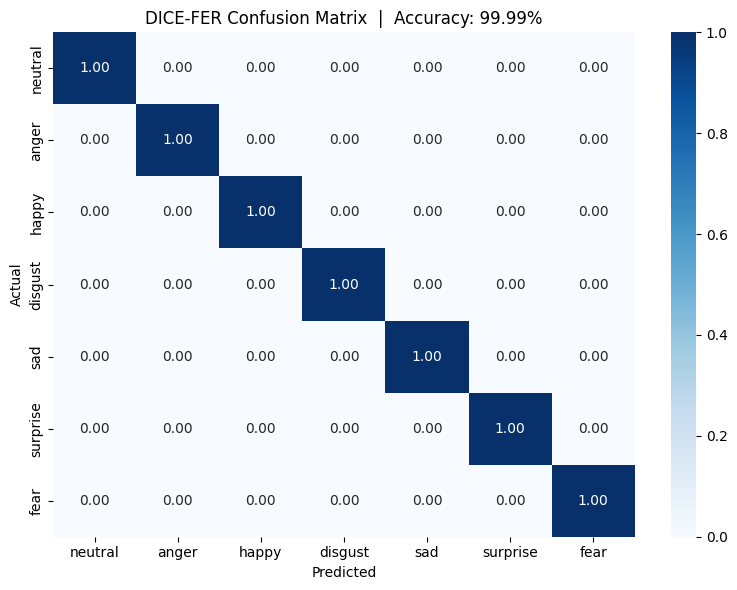

In [12]:
def evaluate_fixed(E_exp, C, data_dir: str, batch_size: int = 32):
    """Confusion matrix + per-class accuracy with explicit label mapping to prevent class mismatches."""
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt
    import torch

    device = next(E_exp.parameters()).device
    dataset = FERDataset(data_dir=data_dir, is_train=False)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    E_exp.eval(); C.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for img_M, _, labels in loader:
            logits = C(E_exp(img_M.to(device)))
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())

    acc = 100.0 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"\nFinal Accuracy: {acc:.2f}%\n")

    class_names = ["neutral", "anger", "happy", "disgust", "sad", "surprise", "fear"]

    explicit_labels = list(range(len(class_names)))

    print("Classification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        labels=explicit_labels,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(all_labels, all_preds, labels=explicit_labels, normalize="true")

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"DICE-FER Confusion Matrix  |  Accuracy: {acc:.2f}%")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

evaluate_fixed(E_exp, C, data_dir="real_data/train")

📸 Please upload a raw image file from your computer:


Saving bearded-young-man-wearing-shirt_273609-5963.avif to bearded-young-man-wearing-shirt_273609-5963.avif


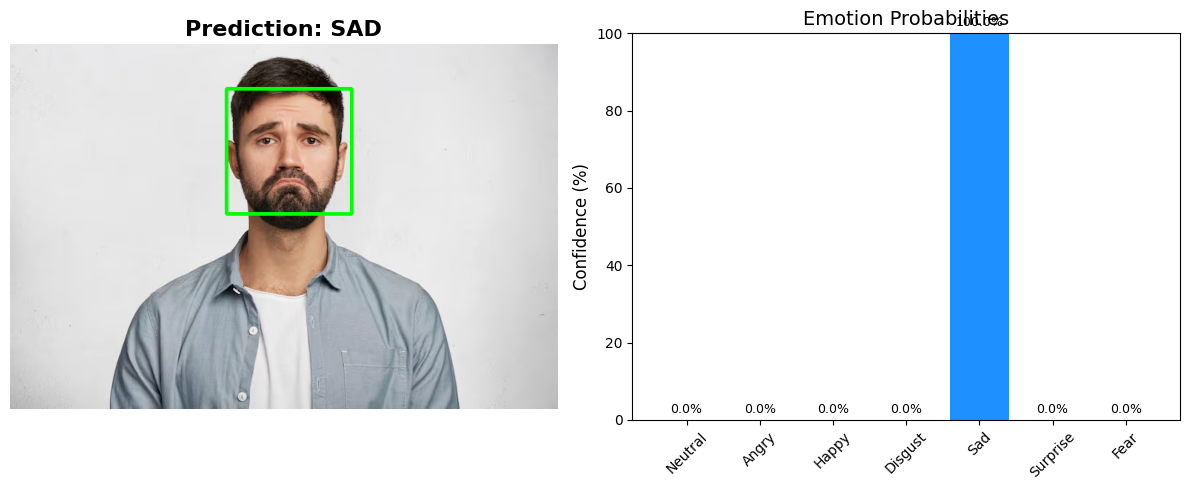

In [20]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import transforms
from google.colab import files

inference_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

emotion_classes = ["Neutral", "Angry", "Happy", "Disgust", "Sad", "Surprise", "Fear"]
device = next(E_exp.parameters()).device

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

E_exp.eval()
C.eval()

print("📸 Please upload a raw image file from your computer:")
uploaded = files.upload()

for filename in uploaded.keys():

    img_bgr = cv2.imread(filename)
    if img_bgr is None:
        print(f"Error: Could not read {filename}.")
        continue

    gray_for_detection = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray_for_detection, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("❌ No face detected in the image! Please try a closer or clearer shot.")
        continue

    x, y, w, h = faces[0]
    face_bgr = img_bgr[y:y+h, x:x+w]
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

    img_with_box = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cv2.rectangle(img_with_box, (x, y), (x+w, y+h), (0, 255, 0), 3)

    input_tensor = inference_transform(face_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        features = E_exp(input_tensor)
        logits = C(features)
        probabilities = F.softmax(logits, dim=1).squeeze().cpu().numpy() * 100

    predicted_idx = np.argmax(probabilities)
    predicted_emotion = emotion_classes[predicted_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.imshow(img_with_box)
    ax1.axis('off')
    ax1.set_title(f"Prediction: {predicted_emotion.upper()}", fontsize=16, fontweight='bold')

    colors = ['gray' if i != predicted_idx else 'dodgerblue' for i in range(7)]
    bars = ax2.bar(emotion_classes, probabilities, color=colors)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('Confidence (%)', fontsize=12)
    ax2.set_title('Emotion Probabilities', fontsize=14)
    ax2.tick_params(axis='x', rotation=45)

    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()